# Examples from pre-trained dataset imagenet1k

### ResNet (careful for the last max pooling layer)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.705042].


The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is Normal mode.
Try to visualize the layer before : 
 Sequential(
  (0): SelectAdaptivePool2d(pool_type=avg, flatten=Flatten(start_dim=1, end_dim=-1))
  (1): Linear(in_features=512, out_features=1000, bias=True)
)
Activation Shape:torch.Size([1, 512, 7, 7])
Prediction_logits Shape:torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 69.8% certainty
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 512])
Shape of weighted Combination between gradients and activations: (7, 7, 512)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 1.2098195552825928
jet_color shape: (256, 3)


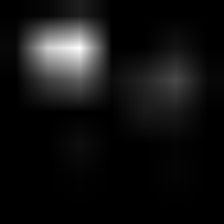

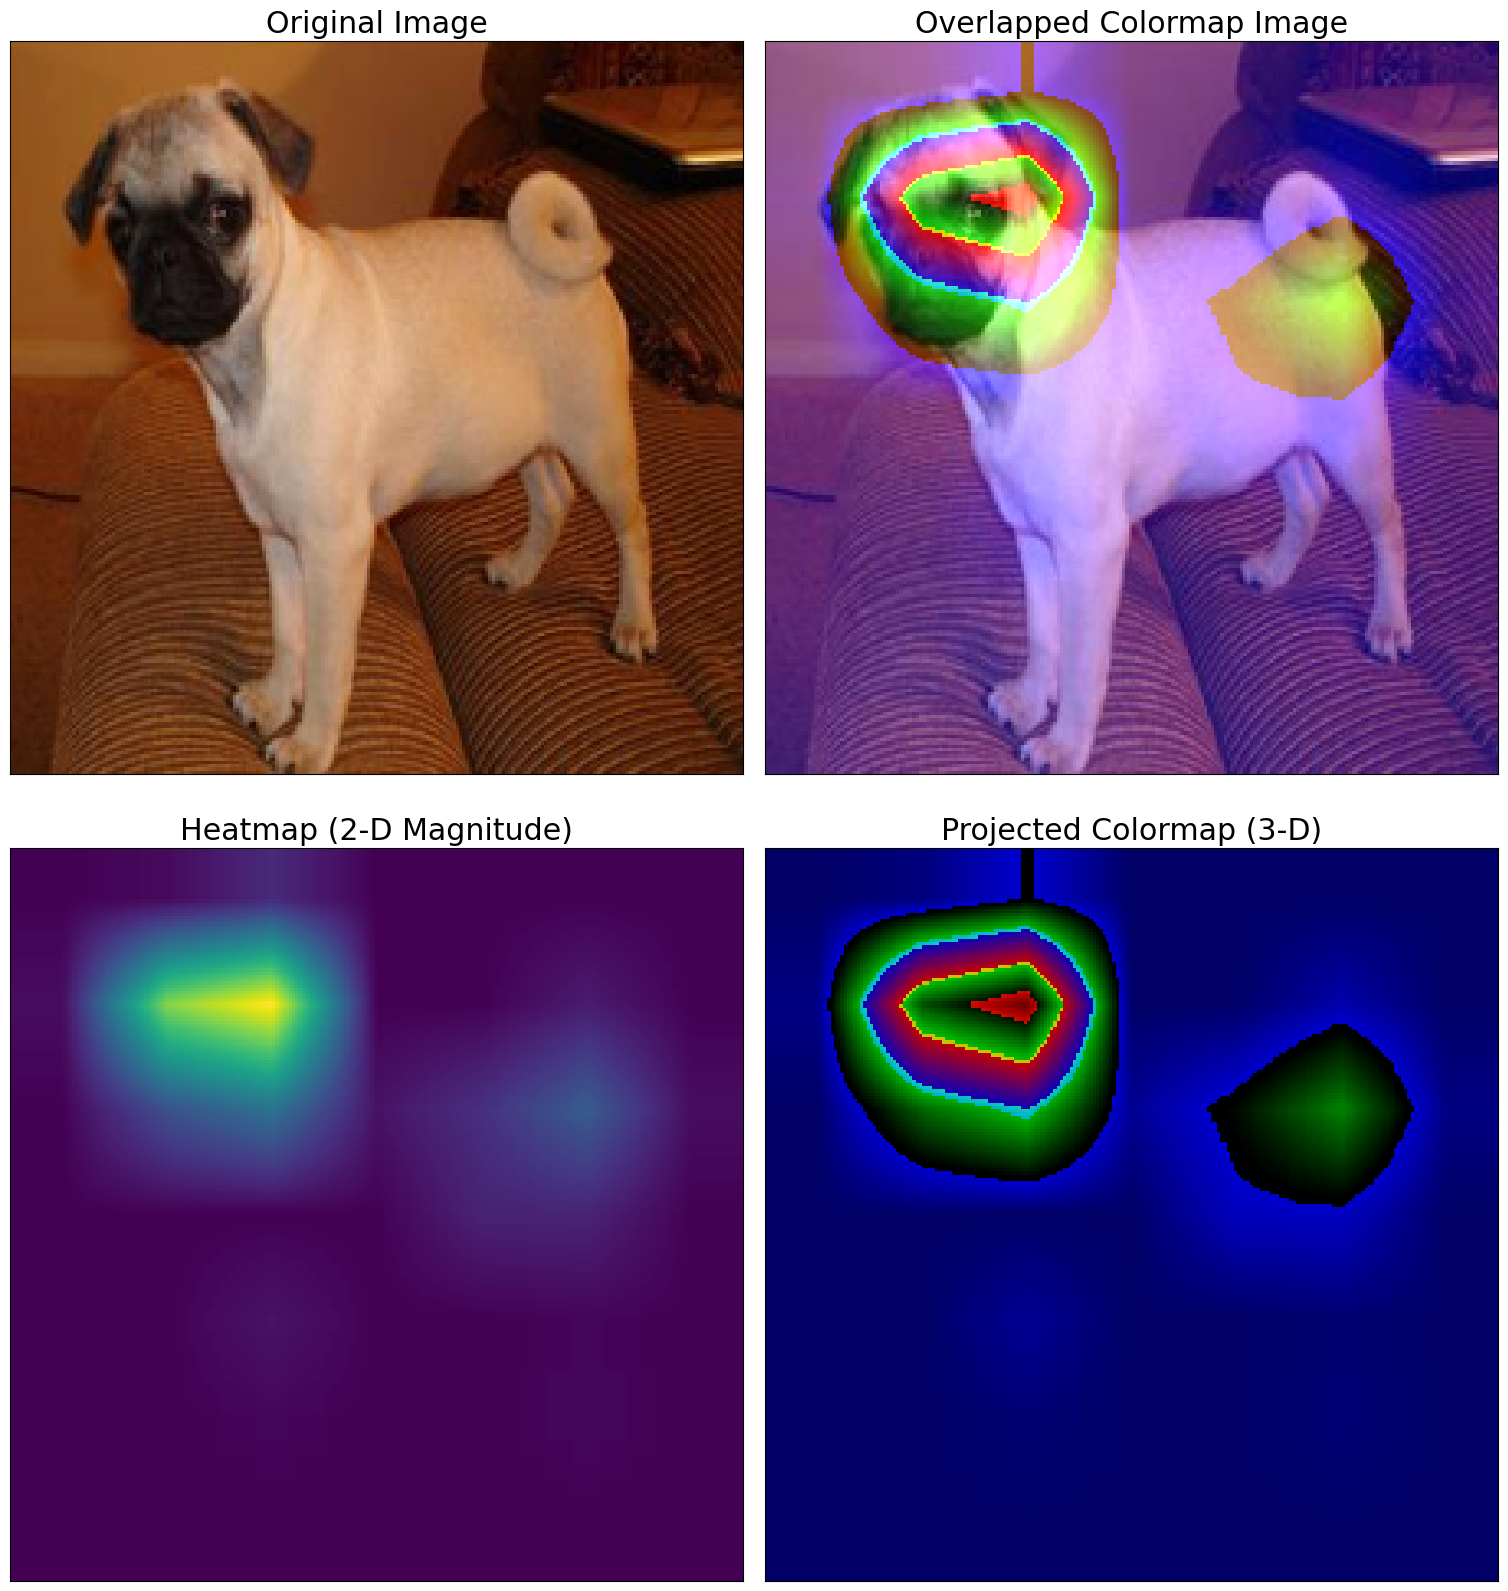

In [1]:
from grad_cam_code.grad_cam import *

#model = create_model('timm/resnet34.a1_in1k', pretrained=True)
model = create_model('timm/resnet18.a1_in1k', pretrained=True)
#model = create_model('timm/resnet10t.c3_in1k', pretrained=True)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'
#img_path = 'graphs/test_images/000000039769.jpg'

# use -1 will raise error since there's a pooling layer before classfication header in ResNet
cam = GradCAM(model,img_path,layer_idx=-2, model_type="Normal", verbose=True) 
cam(heatmap_threshold=100)
cam.imposing_visualization()
cam.heatmap


#### New

In [2]:
from grad_cam_code.grad_cam_new import *
model = create_model('timm/resnet18.a1_in1k', pretrained=True)
model.eval()

print_layername(model)


conv1
bn1
act1
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.drop_block
layer1.0.act1
layer1.0.aa
layer1.0.conv2
layer1.0.bn2
layer1.0.act2
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.drop_block
layer1.1.act1
layer1.1.aa
layer1.1.conv2
layer1.1.bn2
layer1.1.act2
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.drop_block
layer2.0.act1
layer2.0.aa
layer2.0.conv2
layer2.0.bn2
layer2.0.act2
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.drop_block
layer2.1.act1
layer2.1.aa
layer2.1.conv2
layer2.1.bn2
layer2.1.act2
layer3
layer3.0
layer3.0.conv1
layer3.0.bn1
layer3.0.drop_block
layer3.0.act1
layer3.0.aa
layer3.0.conv2
layer3.0.bn2
layer3.0.act2
layer3.0.downsample
layer3.0.downsample.0
layer3.0.downsample.1
layer3.1
layer3.1.conv1
layer3.1.bn1
layer3.1.drop_block
layer3.1.act1
layer3.1.aa
layer3.1.conv2
layer3.1.bn2
layer3.1.act2
layer4
layer4.0
layer4.0.conv1
layer4.0.bn1
layer4.0.drop_block
layer4.0.act1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.53].


The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is Normal mode.
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 69.8% certainty
Activation Shape:torch.Size([1, 512, 7, 7])
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 512])
Shape of weighted Combination between gradients and activations: (7, 7, 512)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 212.9546356201172
jet_color shape: (256, 3)


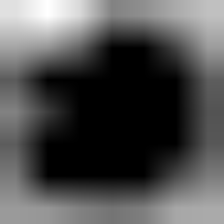

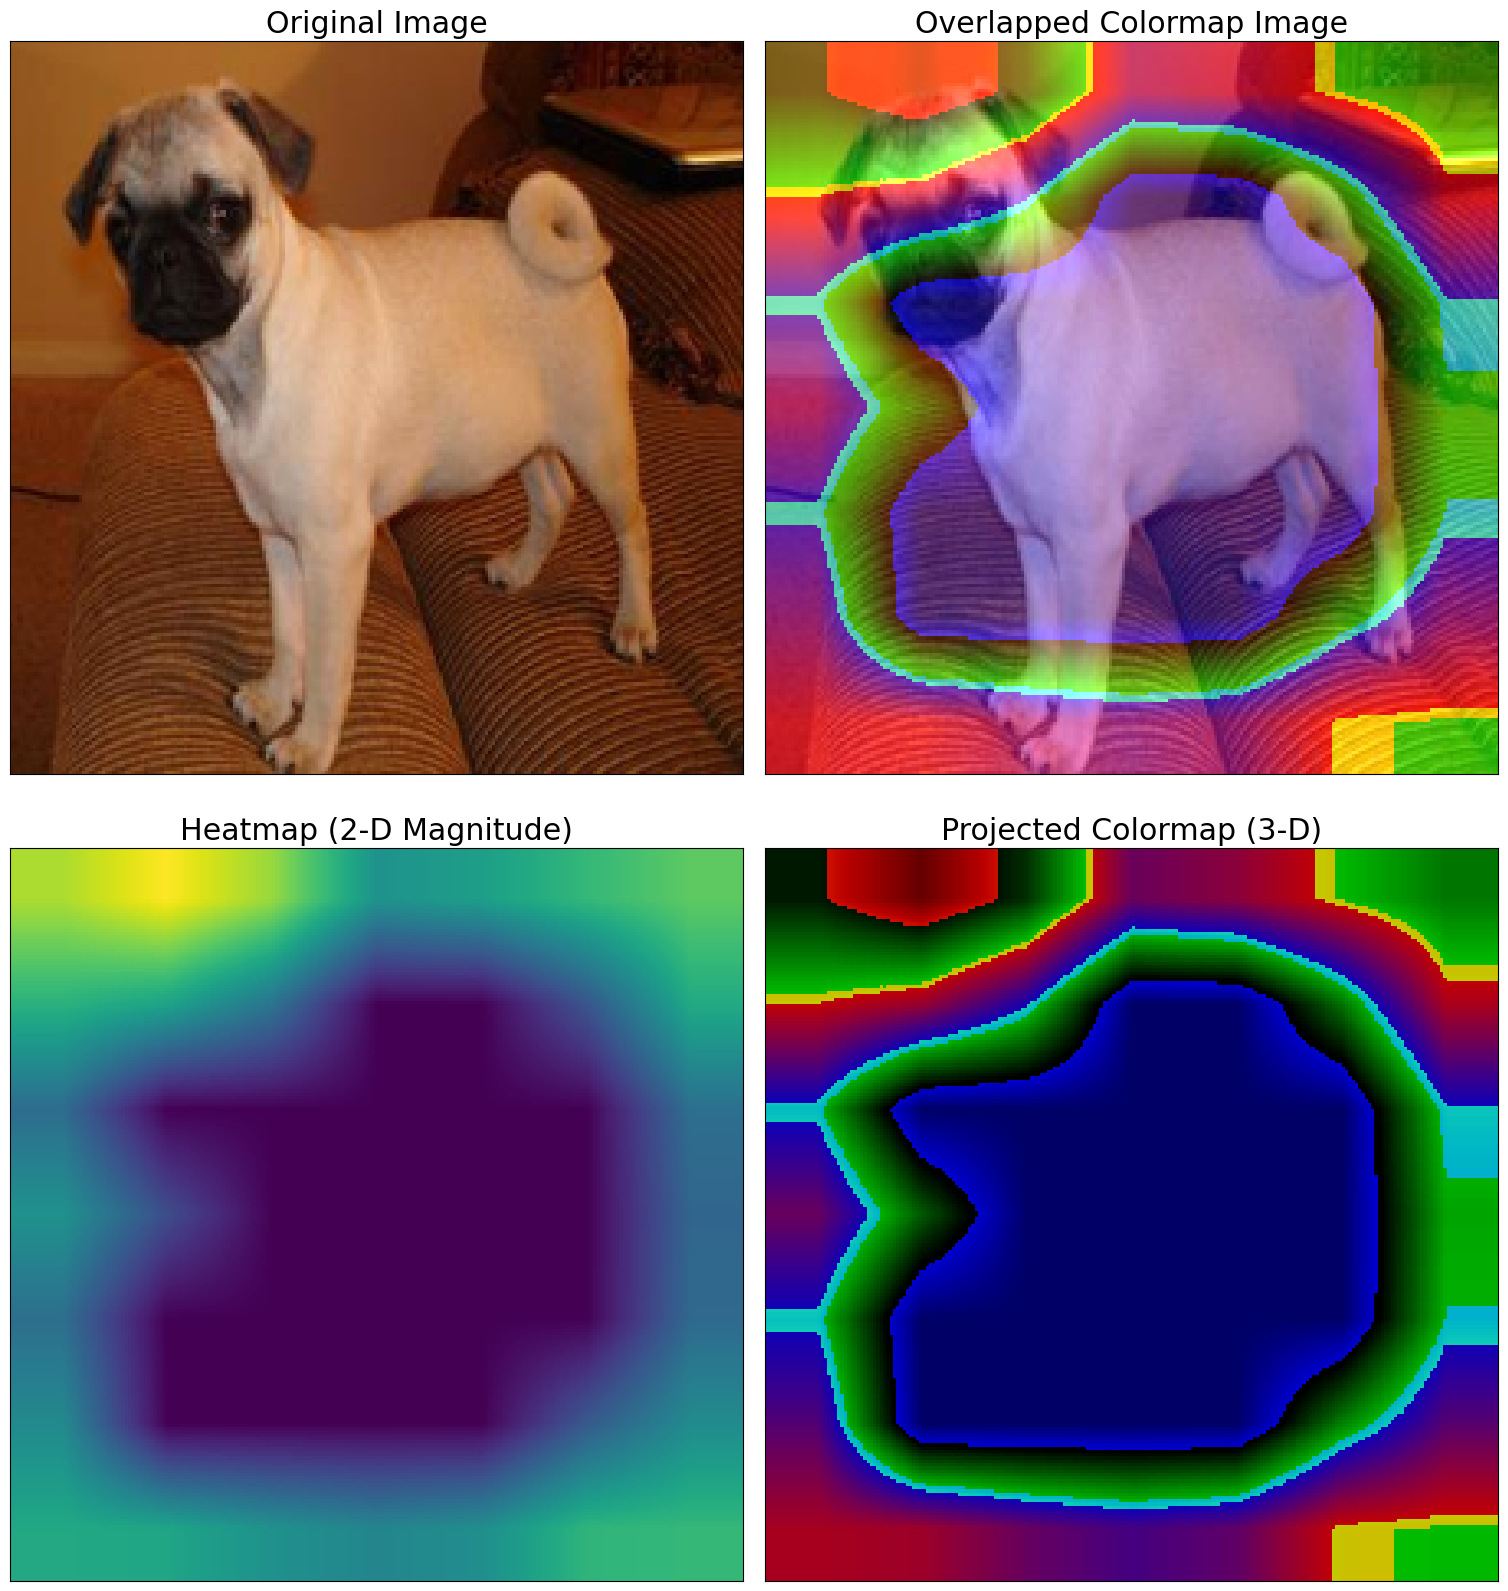

In [3]:
from grad_cam_code.grad_cam_new import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config

model = create_model('timm/resnet18.a1_in1k', pretrained=True)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_name='layer4.1.conv2', model_type='Normal', verbose=True)
cam_vit(heatmap_threshold=5)
cam_vit.imposing_visualization()
cam_vit.heatmap


In [4]:
cam.transform

Compose(
    ToTensor()
)

### Vision Transformer (ViT) model example

The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is ViT mode.
Try to visualize the layer before : 
 Sequential(
  (0): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (1): Identity()
  (2): Dropout(p=0.0, inplace=False)
  (3): Linear(in_features=768, out_features=1000, bias=True)
)
Use the custom transform you provided to preprocess the image
Activation Shape:torch.Size([1, 196, 768])
Prediction_logits Shape:torch.Size([1, 196, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 85.3% certainty


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5997465].


gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 14, 14, 768])
Shape of weighted Combination between gradients and activations: (14, 14, 768)
Shape after channel summation : (14, 14)
Maximum pixel value of heatmap is 0.7389009594917297
jet_color shape: (256, 3)


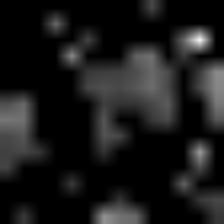

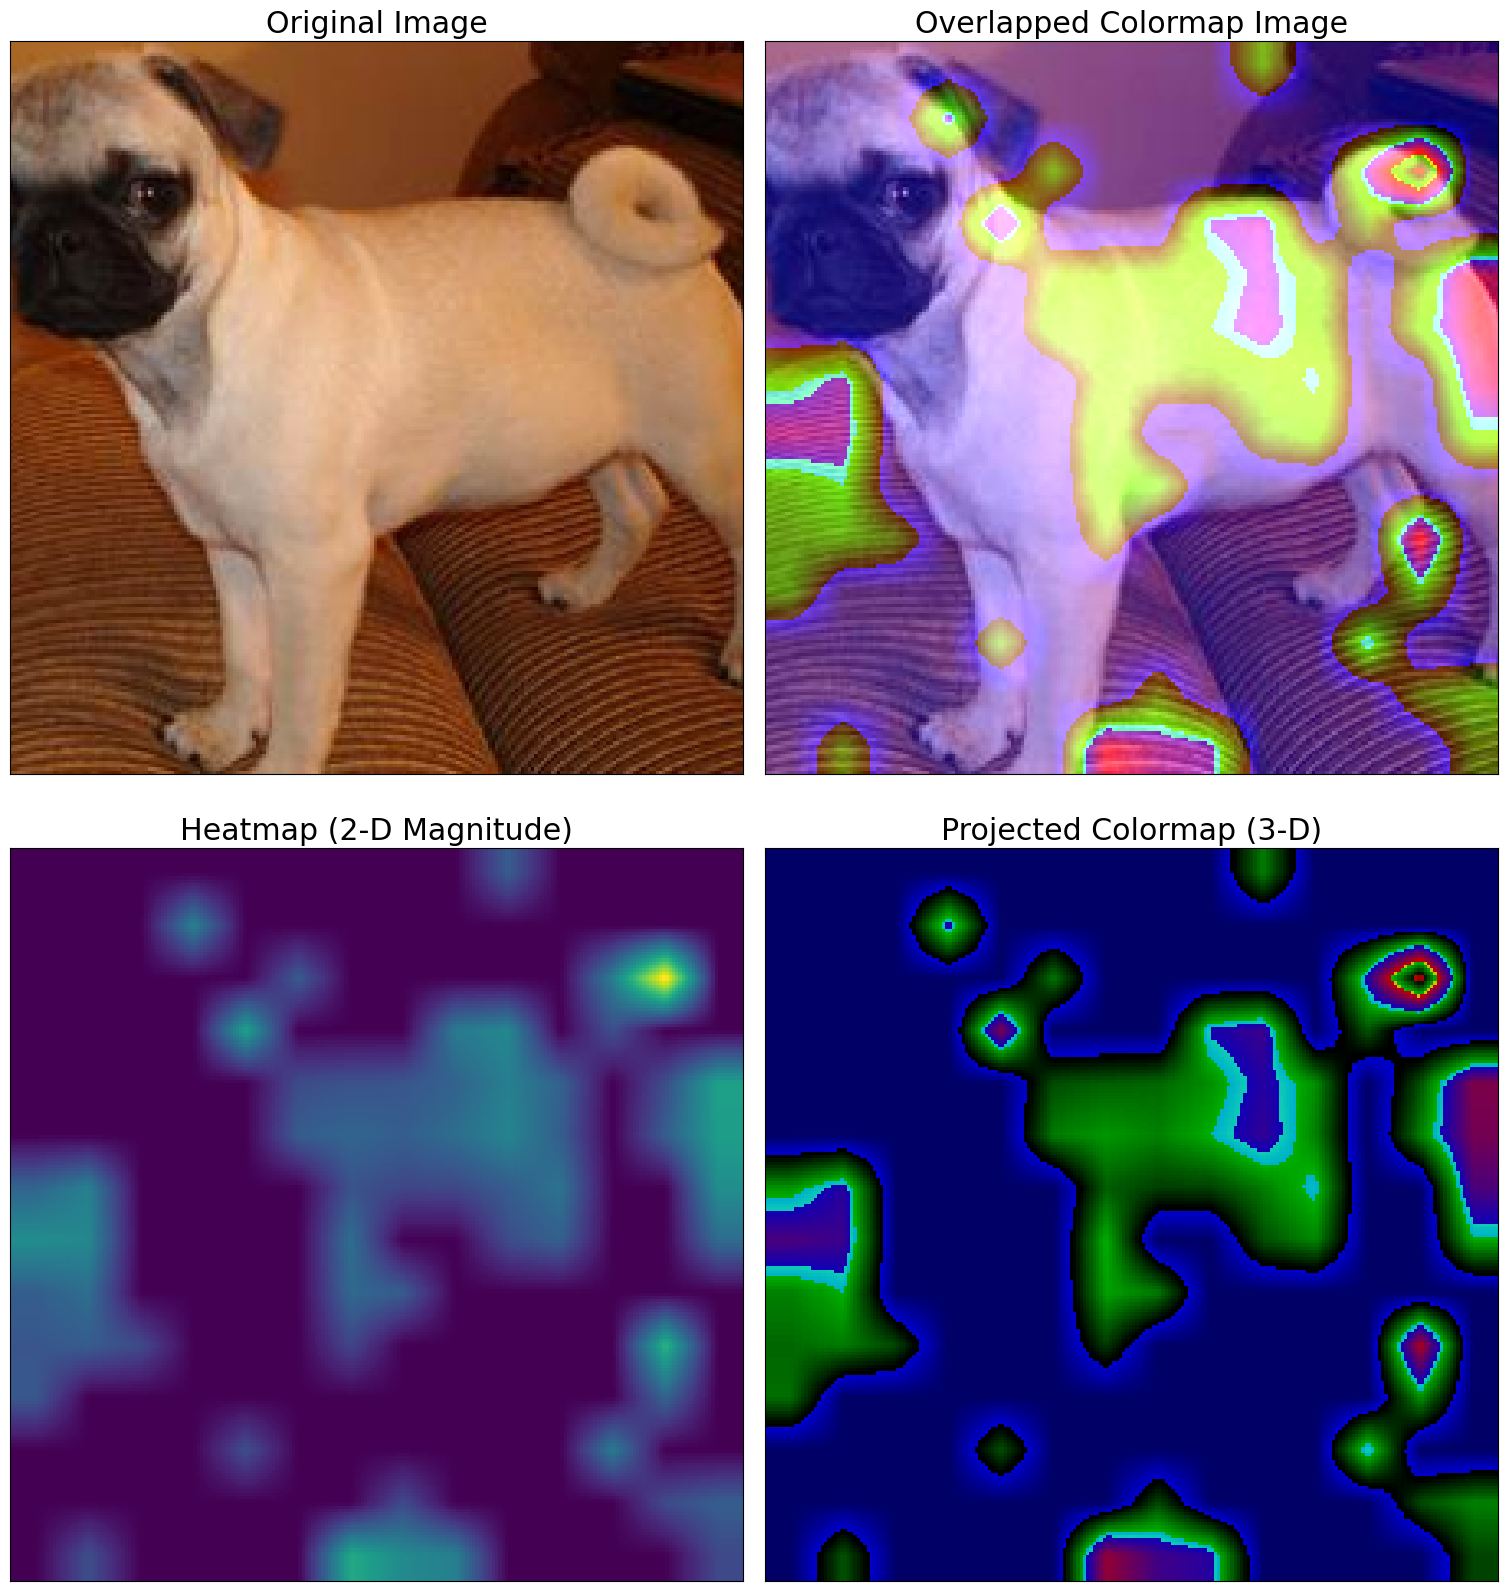

In [5]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config

model = create_model('vit_base_patch16_224', pretrained=True)
## Remember to pass the corresponding preprocessing method, if not using default.
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_idx=-4, model_type='ViT', transform = transform, verbose=True)
cam_vit(heatmap_threshold=5)
cam_vit.imposing_visualization()
cam_vit.heatmap


#### New

The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is ViT mode.
Use the custom transform you provided to preprocess the image
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 85.3% certainty
Activation Shape:torch.Size([1, 197, 768])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3584051].


gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 14, 14, 768])
Shape of weighted Combination between gradients and activations: (14, 14, 768)
Shape after channel summation : (14, 14)
Maximum pixel value of heatmap is 0.12619717419147491
jet_color shape: (256, 3)


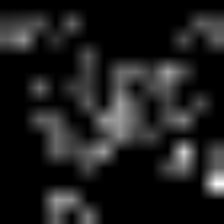

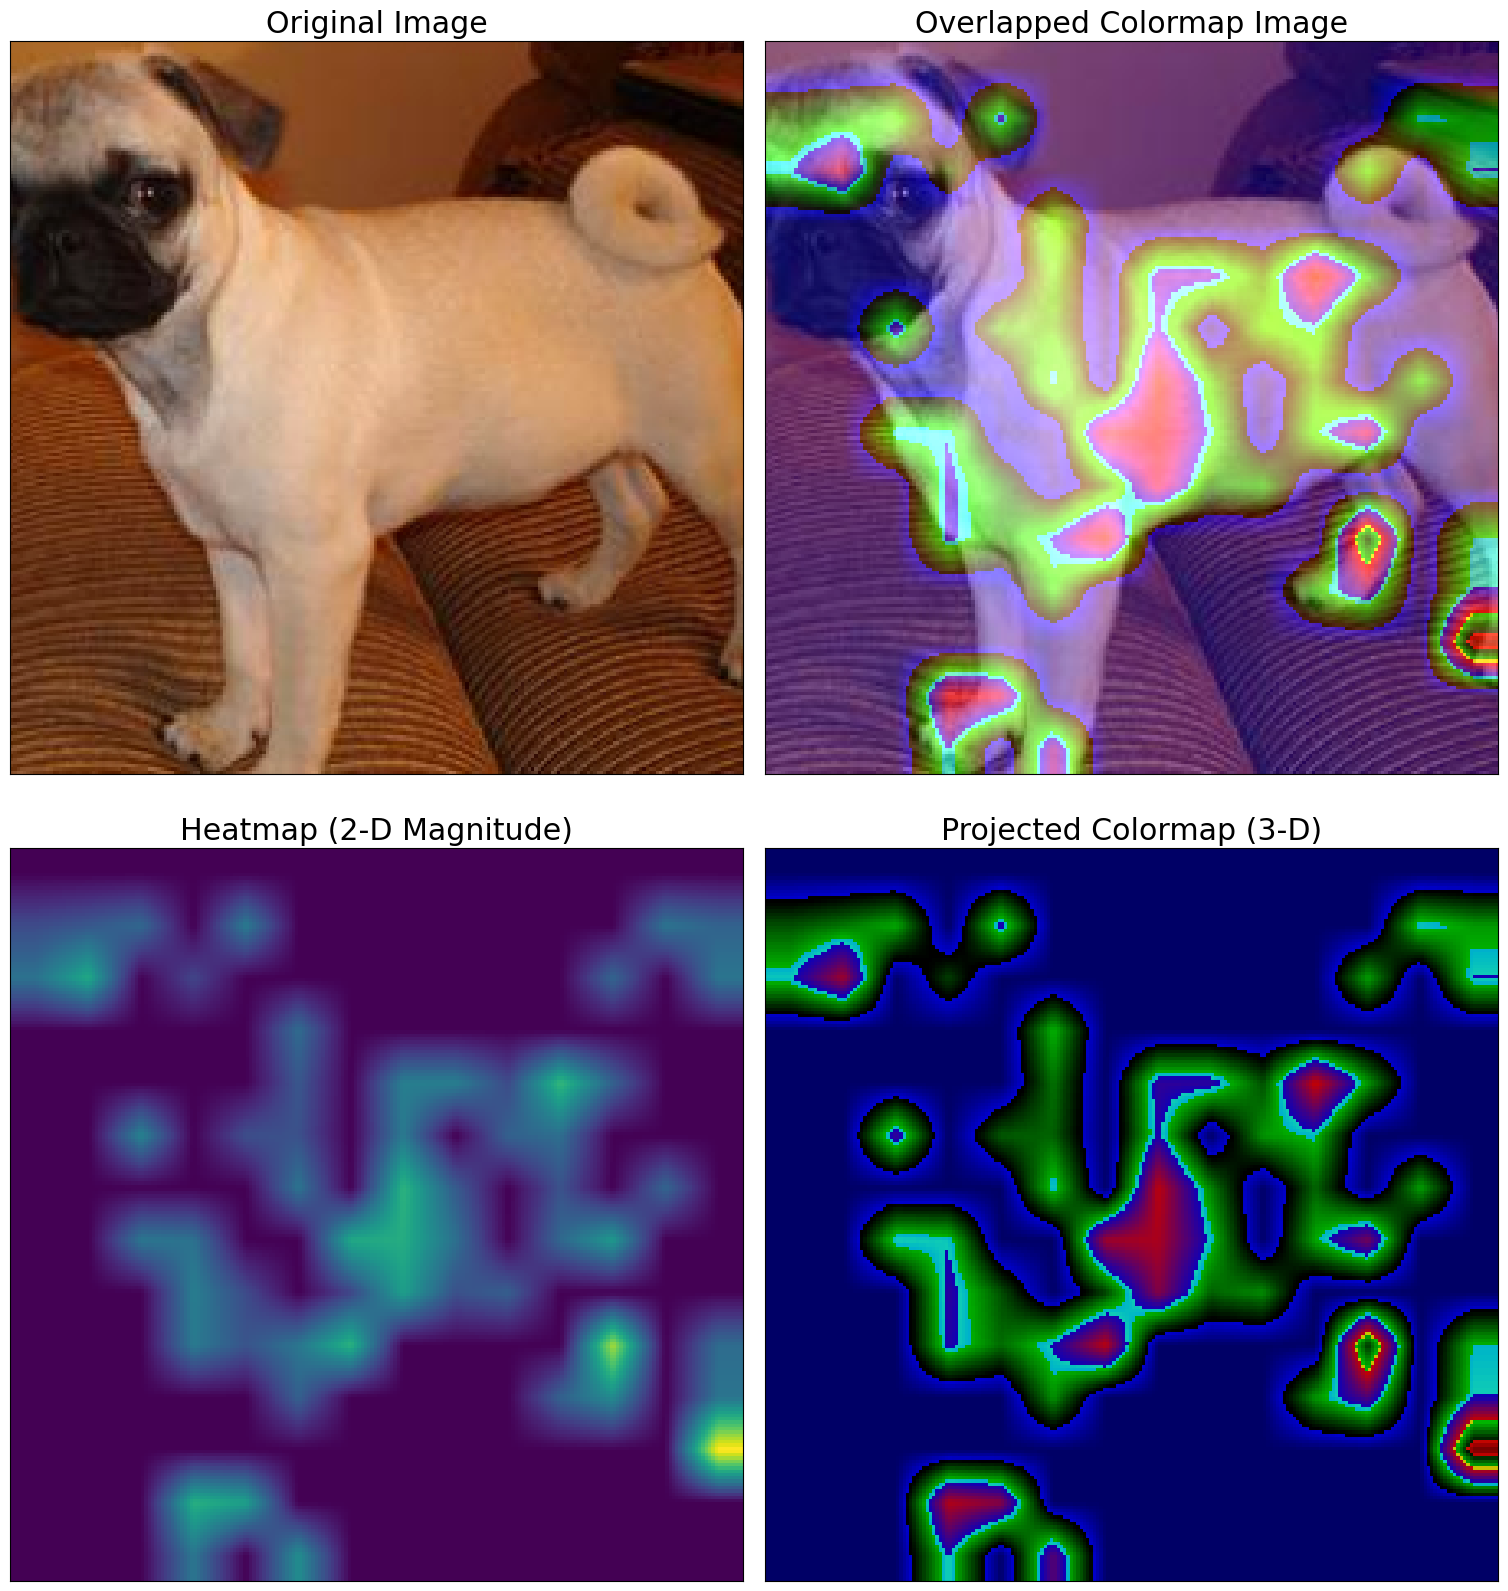

In [6]:
from grad_cam_code.grad_cam_new import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config

model = create_model('vit_base_patch16_224', pretrained=True)
## Remember to pass the corresponding preprocessing method, if not using default.
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_name='blocks.7.drop_path2', model_type='ViT', transform = transform, verbose=True)
cam_vit(heatmap_threshold=5)
cam_vit.imposing_visualization()
cam_vit.heatmap


## Swin Transformer

Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)
The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is SwinT mode.
Try to visualize the layer before : 
 Sequential(
  (0): ClassifierHead(
    (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
    (drop): Dropout(p=0.0, inplace=False)
    (fc): Linear(in_features=1024, out_features=1000, bias=True)
    (flatten): Identity()
  )
)
Use the custom transform you provided to preprocess the image
Activation Shape:torch.Size([1, 7, 7, 1024])
Prediction_logits Shape:torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 81.5% certainty


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7418136649970393e-09..1.654901955861671].


gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 1024])
Shape of weighted Combination between gradients and activations: (7, 7, 1024)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 0.7670761942863464
jet_color shape: (256, 3)


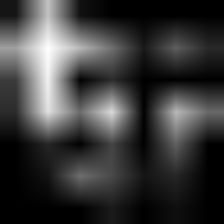

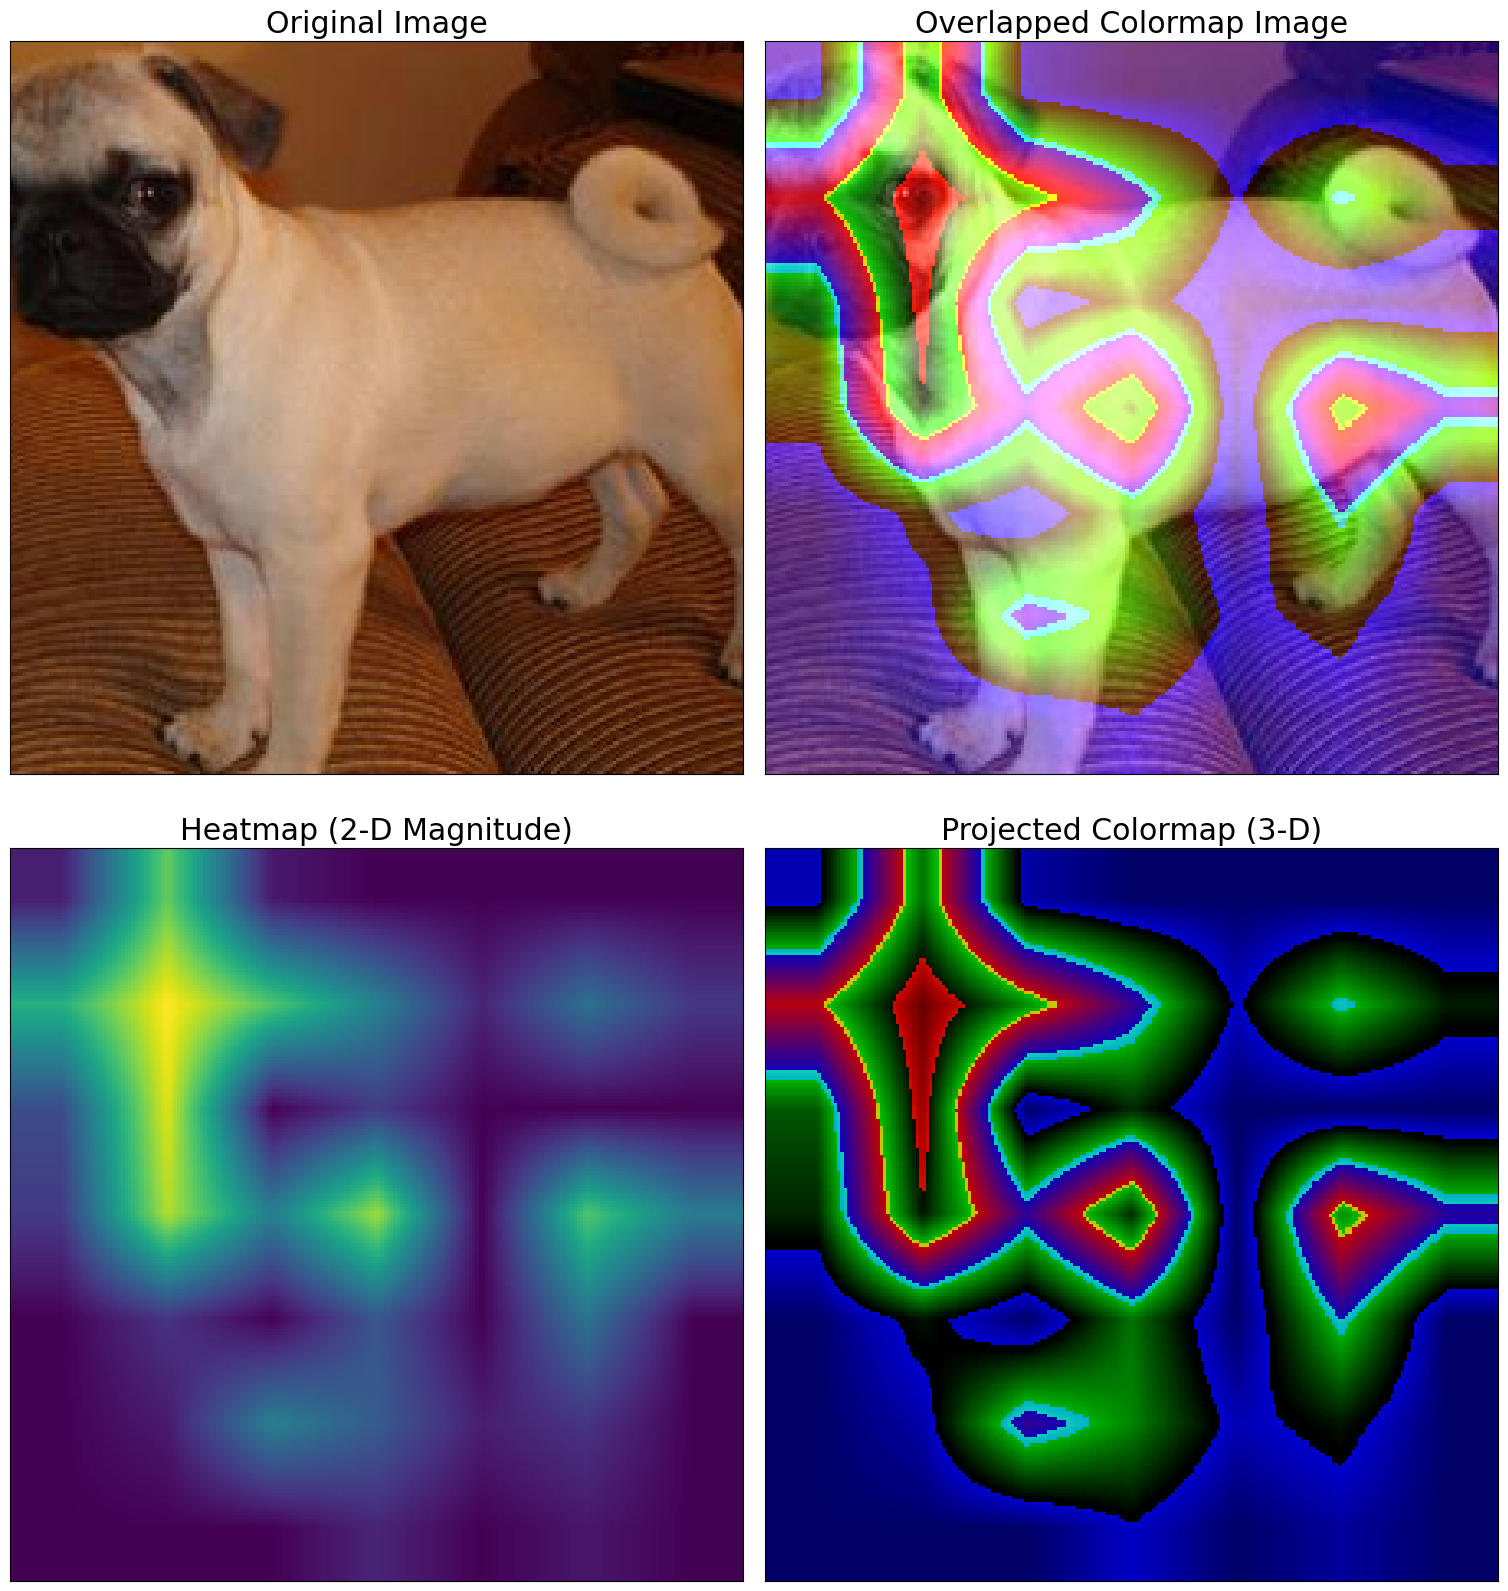

In [7]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config


model = create_model('swin_base_patch4_window7_224', pretrained=True)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
print(transform)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam = GradCAM(model,img_path,layer_idx=-1, model_type='SwinT', auto_find_classfier=True, transform = transform,verbose=True)
cam(heatmap_threshold=20)
cam.imposing_visualization(save_path="img/swt_test", denormalize=([0.4850, 0.4560, 0.4060],[0.2290, 0.2240, 0.2250]))    #specify the normalization method if not using the default when saving the images
cam.heatmap


#### New

In [8]:
from grad_cam_code.grad_cam_new import *
model = create_model('swin_base_patch4_window7_224', pretrained=True)
print_layername(model)


patch_embed
patch_embed.proj
patch_embed.norm
layers
layers.0
layers.0.downsample
layers.0.blocks
layers.0.blocks.0
layers.0.blocks.0.norm1
layers.0.blocks.0.attn
layers.0.blocks.0.attn.qkv
layers.0.blocks.0.attn.attn_drop
layers.0.blocks.0.attn.proj
layers.0.blocks.0.attn.proj_drop
layers.0.blocks.0.attn.softmax
layers.0.blocks.0.drop_path1
layers.0.blocks.0.norm2
layers.0.blocks.0.mlp
layers.0.blocks.0.mlp.fc1
layers.0.blocks.0.mlp.act
layers.0.blocks.0.mlp.drop1
layers.0.blocks.0.mlp.norm
layers.0.blocks.0.mlp.fc2
layers.0.blocks.0.mlp.drop2
layers.0.blocks.0.drop_path2
layers.0.blocks.1
layers.0.blocks.1.norm1
layers.0.blocks.1.attn
layers.0.blocks.1.attn.qkv
layers.0.blocks.1.attn.attn_drop
layers.0.blocks.1.attn.proj
layers.0.blocks.1.attn.proj_drop
layers.0.blocks.1.attn.softmax
layers.0.blocks.1.drop_path1
layers.0.blocks.1.norm2
layers.0.blocks.1.mlp
layers.0.blocks.1.mlp.fc1
layers.0.blocks.1.mlp.act
layers.0.blocks.1.mlp.drop1
layers.0.blocks.1.mlp.norm
layers.0.blocks.1.ml

Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)
The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is SwinT mode.
Use the custom transform you provided to preprocess the image
Output logits shape: torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 81.5% certainty
Activation Shape:torch.Size([1, 49, 1024])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.3305416152474833e-09..1.2933333334565162].


gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 1024])
Shape of weighted Combination between gradients and activations: (7, 7, 1024)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 5.967986583709717
jet_color shape: (256, 3)


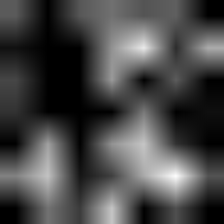

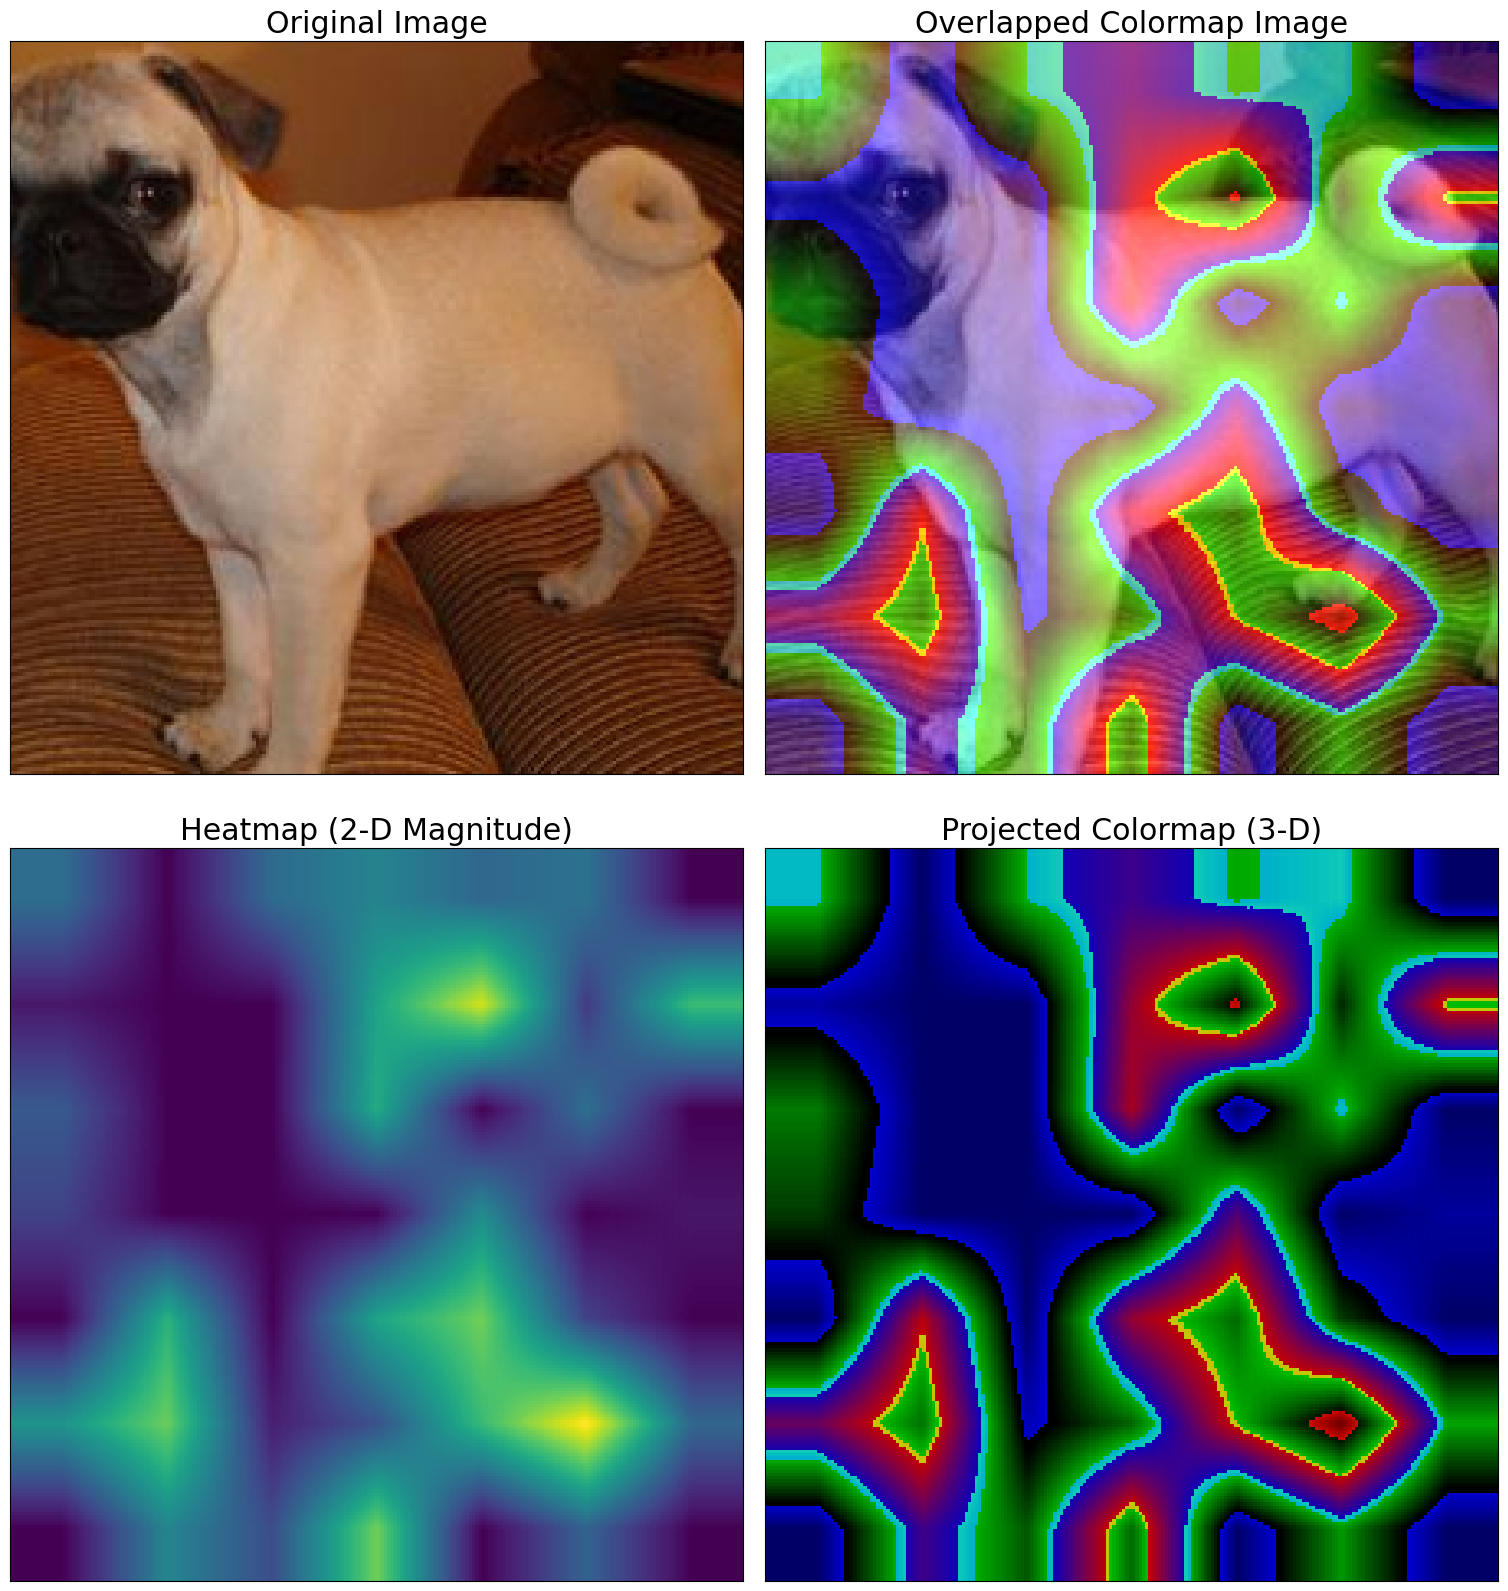

In [9]:
from grad_cam_code.grad_cam_new import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config


model = create_model('swin_base_patch4_window7_224', pretrained=True)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
print(transform)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam = GradCAM(model,img_path,layer_name='layers.3.blocks.1.drop_path2', model_type='SwinT', transform = transform,verbose=True)
cam(heatmap_threshold=20)
cam.imposing_visualization(save_path="img/swt_test", denormalize=([0.4850, 0.4560, 0.4060],[0.2290, 0.2240, 0.2250]))    #specify the normalization method if not using the default when saving the images
cam.heatmap
